In [ ]:
%pip install wooldridge

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 8.8 MB/s  0:00:00m eta 0:00:01

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Data preparation for the Sleep and the Allocation of Time project

import pandas as pd
import numpy as np

# If needed:
# pip install wooldridge

import wooldridge as wd

# Load dataset
sleep75 = wd.data("sleep75")

# Basic inspection
print("Dataset shape:", sleep75.shape)
print("\nFirst rows:")
print(sleep75.head())

print("\nVariable types:")
print(sleep75.dtypes)

print("\nMissing values:")
print(sleep75.isna().sum().sort_values(ascending=False))

Dataset shape: (706, 34)

First rows:
   age  black  case  clerical  construc  educ  earns74  gdhlth  inlf  leis1  \
0   32      0     1       0.0       0.0    12      0.0       0     1   3529   
1   31      0     2       0.0       0.0    14   9500.0       1     1   2140   
2   44      0     3       0.0       0.0    17  42500.0       1     1   4595   
3   30      0     4       0.0       0.0    12  42500.0       1     1   3211   
4   64      0     5       0.0       0.0    14   2500.0       1     1   4052   

   ...  spwrk75  totwrk  union  worknrm  workscnd  exper  yngkid  yrsmarr  \
0  ...        0    3438      0     3438         0     14       0       13   
1  ...        0    5020      0     5020         0     11       0        0   
2  ...        1    2815      0     2815         0     21       0        0   
3  ...        1    3786      0     3786         0     12       0       12   
4  ...        1    2580      0     2580         0     44       0       33   

      hrwage  agesq  
0 

In [2]:
# Choose dependent variable
# Project instruction:
# male analyst -> sleep
# female analyst -> slpnaps

analyst_gender = "male"   # change to "female" if needed

if analyst_gender == "male":
    sleep75["sleep_response"] = sleep75["sleep"]
    response_label = "Minutes of night sleep per week"
else:
    sleep75["sleep_response"] = sleep75["slpnaps"]
    response_label = "Minutes of sleep per week including naps"

print("Selected response variable:", response_label)

Selected response variable: Minutes of night sleep per week


In [3]:
# Select variables for the analytical dataset

selected_columns = [
    "sleep_response",
    "sleep",
    "slpnaps",
    "totwrk",
    "educ",
    "age",
    "agesq",
    "male",
    "marr",
    "yngkid",
    "gdhlth",
    "inlf",
    "hrwage",
    "lhrwage"
]

df = sleep75[selected_columns].copy()

# Check missing values in selected dataset
missing_summary = df.isna().sum().sort_values(ascending=False)
print(missing_summary)

lhrwage           174
hrwage            174
slpnaps             0
totwrk              0
sleep_response      0
sleep               0
age                 0
educ                0
agesq               0
male                0
yngkid              0
marr                0
inlf                0
gdhlth              0
dtype: int64


In [4]:
# Create additional useful variables

df["work_hours_week"] = df["totwrk"] / 60
df["sleep_hours_week"] = df["sleep_response"] / 60
df["sleep_hours_day"] = df["sleep_response"] / 7 / 60

# Dummy showing whether hourly wage is observed
df["wage_observed"] = df["hrwage"].notna().astype(int)

# Optional: dummy for non-workers or people outside the labour force
df["not_in_labor_force"] = (df["inlf"] == 0).astype(int)

print(df.head())

   sleep_response  sleep  slpnaps  totwrk  educ  age  agesq  male  marr  \
0            3113   3113     3163    3438    12   32   1024     1     1   
1            2920   2920     2920    5020    14   31    961     1     0   
2            2670   2670     2760    2815    17   44   1936     1     1   
3            3083   3083     3083    3786    12   30    900     0     1   
4            3448   3448     3493    2580    14   64   4096     1     1   

   yngkid  gdhlth  inlf     hrwage   lhrwage  work_hours_week  \
0       0       0     1   7.070004  1.955861        57.300000   
1       0       1     1   1.429999  0.357674        83.666667   
2       0       1     1  20.529997  3.021887        46.916667   
3       0       1     1   9.619998  2.263844        63.100000   
4       0       1     1   2.750000  1.011601        43.000000   

   sleep_hours_week  sleep_hours_day  wage_observed  not_in_labor_force  
0         51.883333         7.411905              1                   0  
1         

In [5]:
# Basic sanity checks

print("Summary of main variables:")
print(df[[
    "sleep_response",
    "sleep_hours_day",
    "totwrk",
    "work_hours_week",
    "educ",
    "age",
    "hrwage"
]].describe())

# Check whether there are impossible values
print("\nNegative values check:")
print((df[["sleep_response", "totwrk", "educ", "age"]] < 0).sum())

# Check wage missingness by labour force status
print("\nWage observed by labour force status:")
print(pd.crosstab(df["inlf"], df["wage_observed"], margins=True))

Summary of main variables:
       sleep_response  sleep_hours_day       totwrk  work_hours_week  \
count      706.000000       706.000000   706.000000       706.000000   
mean      3266.355524         7.777037  2122.920680        35.382011   
std        444.413448         1.058127   947.470123        15.791169   
min        755.000000         1.797619     0.000000         0.000000   
25%       3015.000000         7.178571  1553.500000        25.891667   
50%       3270.500000         7.786905  2288.000000        38.133333   
75%       3532.250000         8.410119  2691.750000        44.862500   
max       4695.000000        11.178571  6415.000000       106.916667   

             educ         age      hrwage  
count  706.000000  706.000000  532.000000  
mean    12.780453   38.815864    5.082839  
std      2.784702   11.342637    3.704385  
min      1.000000   23.000000    0.350000  
25%     12.000000   29.000000    2.890002  
50%     12.000000   36.000000    4.379999  
75%     16.00000

In [6]:
# Save cleaned dataset for other group members

df.to_csv("sleep75_cleaned.csv", index=False)

print("Cleaned dataset saved as sleep75_cleaned.csv")

Cleaned dataset saved as sleep75_cleaned.csv


In [7]:
df = pd.read_csv("sleep75_cleaned.csv")

print(df.describe())

       sleep_response        sleep      slpnaps       totwrk        educ  \
count      706.000000   706.000000   706.000000   706.000000  706.000000   
mean      3266.355524  3266.355524  3383.083569  2122.920680   12.780453   
std        444.413448   444.413448   499.046930   947.470123    2.784702   
min        755.000000   755.000000  1335.000000     0.000000    1.000000   
25%       3015.000000  3015.000000  3105.750000  1553.500000   12.000000   
50%       3270.500000  3270.500000  3369.000000  2288.000000   12.000000   
75%       3532.250000  3532.250000  3655.000000  2691.750000   16.000000   
max       4695.000000  4695.000000  6110.000000  6415.000000   17.000000   

              age        agesq        male       marr      yngkid      gdhlth  \
count  706.000000   706.000000  706.000000  706.00000  706.000000  706.000000   
mean    38.815864  1635.144476    0.566572    0.82153    0.128895    0.890935   
std     11.342637   950.102976    0.495900    0.38318    0.335321    0.3

ValueError: Invalid RGBA argument: 'my_colors'

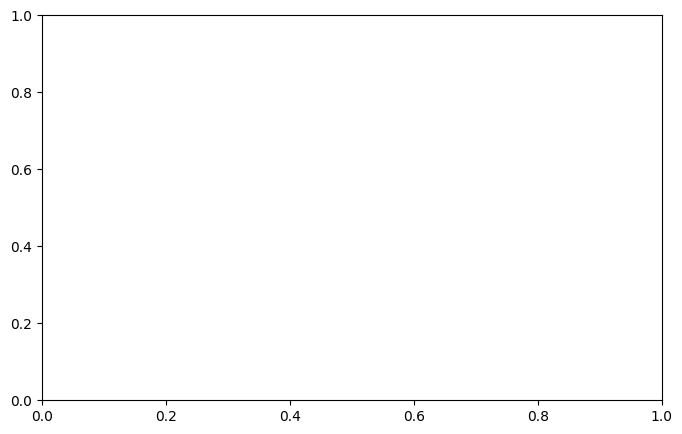

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
my_colors= ['hotpink', 'purple', 'hotpink', 'purple']
sns.histplot(df["sleep_response"], bins=30, kde=True , color="my_colors")
plt.bar(x, y, color=my_colors)

plt.title("Distribution of Sleep Time")
plt.xlabel("Minutes per Week")
plt.ylabel("Frequency") 
plt.show()

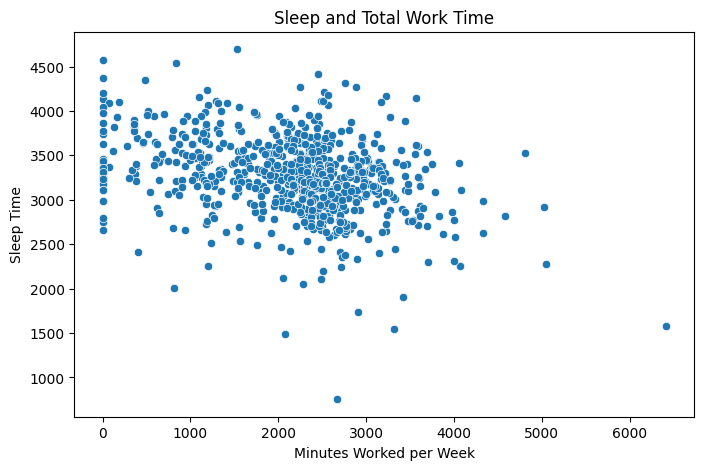

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="totwrk",
    y="sleep_response"
    
)

plt.title("Sleep and Total Work Time")
plt.xlabel("Minutes Worked per Week")
plt.ylabel("Sleep Time")
plt.show()

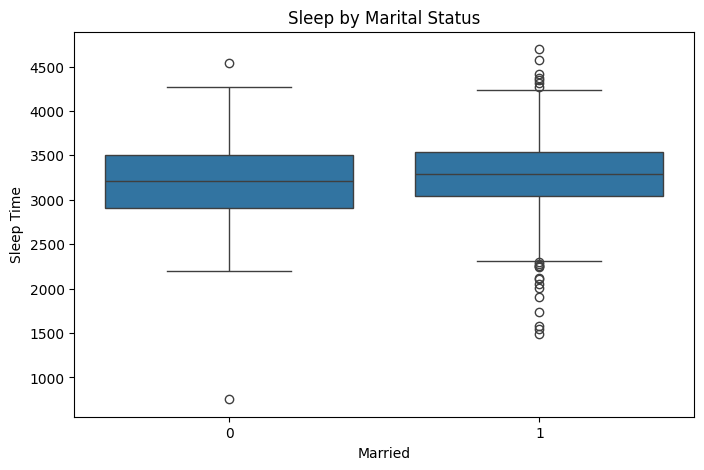

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="marr",
    y="sleep_response"
)

plt.title("Sleep by Marital Status")
plt.xlabel("Married")
plt.ylabel("Sleep Time")
plt.show()

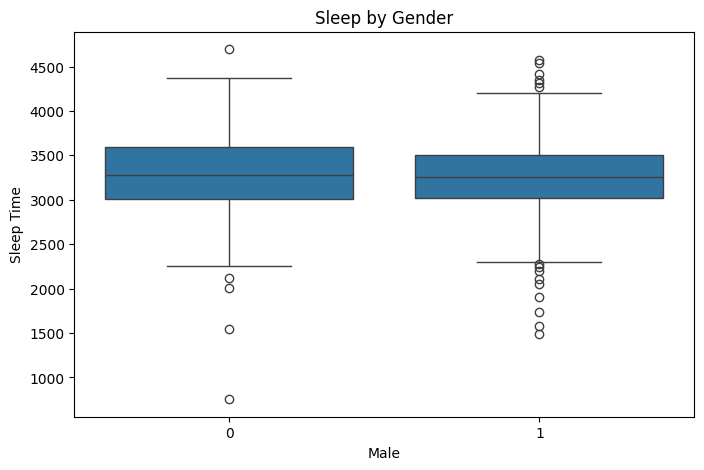

In [19]:

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="male",
    y="sleep_response"
)

plt.title("Sleep by Gender")
plt.xlabel("Male")
plt.ylabel("Sleep Time")
plt.show()

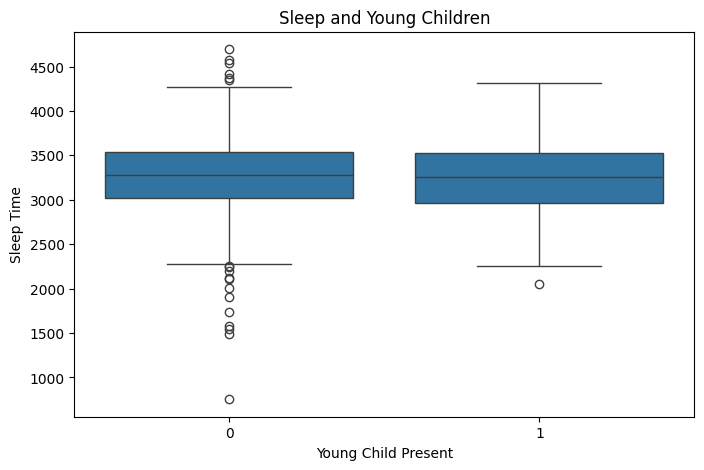

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="yngkid",
    y="sleep_response"
)

plt.title("Sleep and Young Children")
plt.xlabel("Young Child Present")
plt.ylabel("Sleep Time")
plt.show()

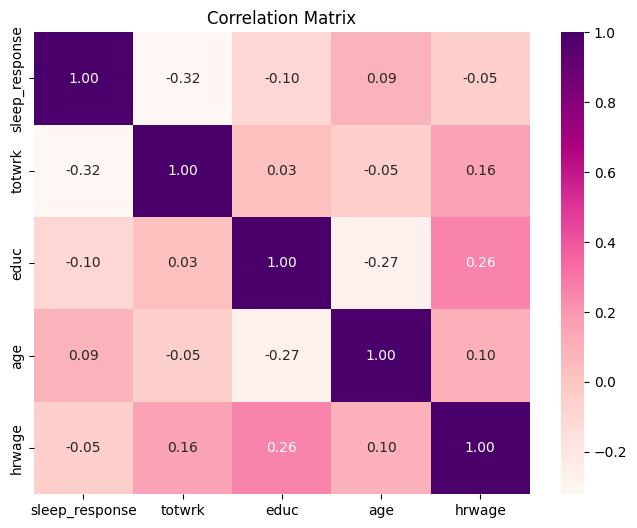

In [ ]:
corr_vars = [
    "sleep_response",
    "totwrk",
    "educ",
    "age",
    "hrwage"
]

corr = df[corr_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="RdPu",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show() 
